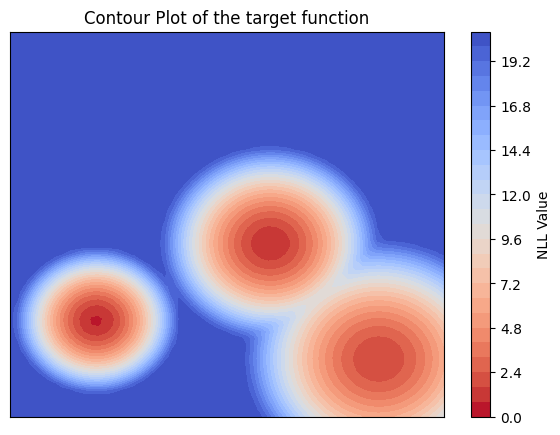

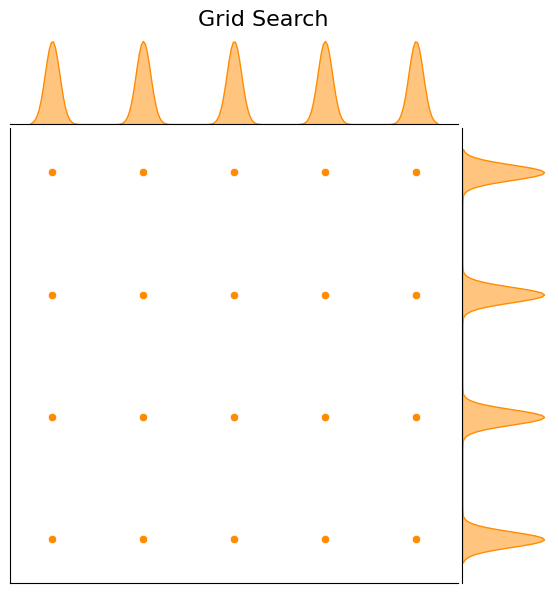

/Users/teshima/lecture-supplement-material/Introduction-to-AI/.venv/lib/python3.11/site-packages/scipy/stats/_qmc.py:958: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)


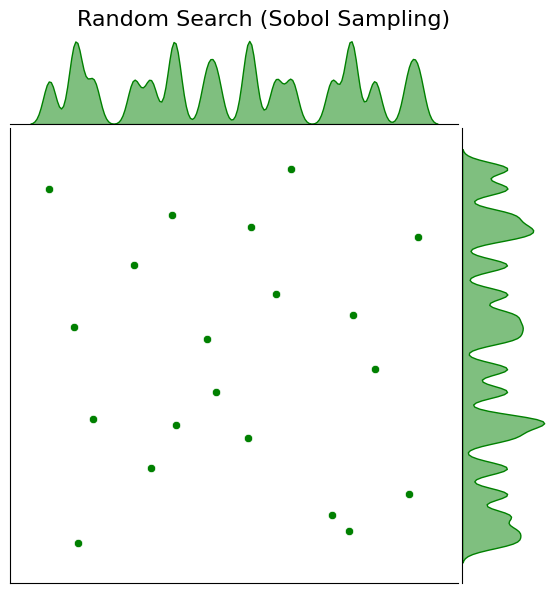

/Users/teshima/lecture-supplement-material/Introduction-to-AI/.venv/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/teshima/lecture-supplement-material/Introduction-to-AI/.venv/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:659: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/teshima/lecture-supplement-material/Introduction-to-AI/.venv/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:659: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increas

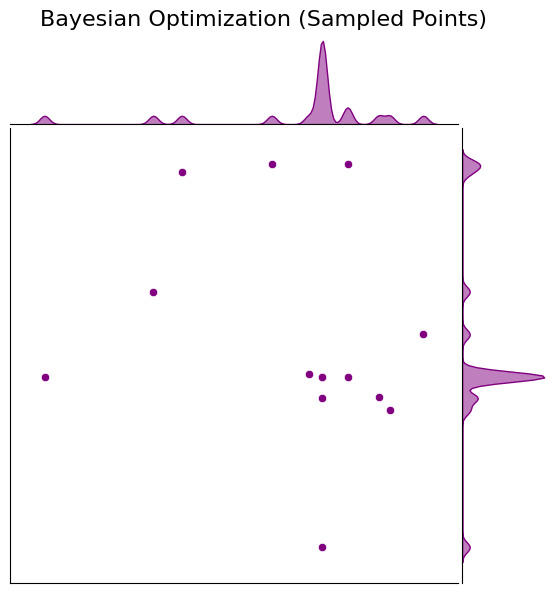

Best results:
  - Grid Search:    NLL=5.9848 at (lambda1, lambda2)=[25.075  0.334]
  - Random Search:  NLL=2.9773 at (lambda1, lambda2)=[92.90378869  0.13098381]
  - Bayesian Opt.:  NLL=1.2378 at (lambda1, lambda2)=[57.93684211  0.47421053]


In [4]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats.qmc import Sobol
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# -------------------------------
# 1) Setup
# -------------------------------
# Fix global seed for any other random calls
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

color_palette = {
    "white": "#FFFFFF",
    "light_gray": "#D3D3D3",
    "gray": "#808080",
    "black": "#000000",
    "green": "#008000",
    "blue": "#0000FF",
    "light_blue": "#ADD8E6",
    "light_light_blue": "#E0FFFF",
    "yellow": "#FFFF00",
    "orange": "#FFA500",
    "dark_orange": "#FF8C00",
    "purple": "#800080"
}

# -------------------------------
# 2) Define a three-Gaussian mixture negative log-likelihood (sharp minima)
# -------------------------------
def three_gaussian_neg_log_likelihood_sharp(x):
    x = np.atleast_2d(x)
    lam1, lam2 = x[:, 0], x[:, 1]

    # Means
    mu1 = np.array([20, 0.25])
    mu2 = np.array([60, 0.45])
    mu3 = np.array([85, 0.15])

    # Smaller standard deviations => sharper peaks
    sigma1 = np.array([3, 0.03])
    sigma2 = np.array([4, 0.04])
    sigma3 = np.array([5, 0.05])

    # Weights
    w1, w2, w3 = 0.3, 0.4, 0.3

    def diag_gauss_pdf(xx, mu, sigma):
        diff = (xx - mu) / sigma
        exponent = -0.5 * np.sum(diff**2, axis=1)
        norm_const = 2.0 * np.pi * sigma[0] * sigma[1]
        return np.exp(exponent) / norm_const

    g1 = diag_gauss_pdf(x, mu1, sigma1)
    g2 = diag_gauss_pdf(x, mu2, sigma2)
    g3 = diag_gauss_pdf(x, mu3, sigma3)

    likelihood = w1*g1 + w2*g2 + w3*g3
    return -np.log(likelihood + 1e-9)

# Parameter ranges
lambda1_range = (0.1, 100)
lambda2_range = (0.001, 1)

# -------------------------------
# 3) Contour plot of the NLL (Warm -> Low, Cool -> High)
# -------------------------------
def plot_target_contour(f, lam1_range, lam2_range, n=60):
    lam1_vals = np.linspace(*lam1_range, n)
    lam2_vals = np.linspace(*lam2_range, n)
    L1, L2 = np.meshgrid(lam1_vals, lam2_vals)
    
    # Evaluate NLL
    Z = f(np.column_stack([L1.ravel(), L2.ravel()])).reshape(L1.shape)
    
    # We reverse a built-in colormap so that warm colors indicate LOWER values
    # and cooler colors indicate HIGHER values.
    # E.g. 'coolwarm_r' or 'inferno_r' or 'hot_r'
    cmap_reversed = plt.cm.coolwarm_r
    
    plt.figure(figsize=(7, 5))
    contour = plt.contourf(L1, L2, Z, levels=30, cmap=cmap_reversed)
    plt.colorbar(contour, label='NLL Value')
    # plt.xlabel(r'$\lambda_1$')
    # plt.ylabel(r'$\lambda_2$')
    plt.xticks([])
    plt.yticks([])
    plt.title('Contour Plot of the target function')
    plt.show()

plot_target_contour(three_gaussian_neg_log_likelihood_sharp, lambda1_range, lambda2_range, n=60)

# -------------------------------
# 4) Utility for scatter + marginals
# -------------------------------
def plot_with_marginals(lambda1, lambda2, color, title):
    g = sns.jointplot(
        x=lambda1,
        y=lambda2,
        kind="scatter",
        marginal_ticks=False,
        color=color_palette[color],
        height=6,
        ratio=5,
        space=0.05
    )

    # Replace default marginal hist with KDE
    g.ax_marg_x.clear()
    g.ax_marg_y.clear()

    sns.kdeplot(
        x=lambda1, ax=g.ax_marg_x, fill=True,
        color=color_palette[color], alpha=0.5, bw_adjust=0.1
    )
    sns.kdeplot(
        y=lambda2, ax=g.ax_marg_y, fill=True,
        color=color_palette[color], alpha=0.5, bw_adjust=0.1
    )

    # Remove ticks/labels from marginals
    for ax in [g.ax_marg_x, g.ax_marg_y]:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(left=False, right=False, labelleft=False,
                       labelbottom=False, bottom=False, top=False)

    g.set_axis_labels()
    plt.suptitle(title, fontsize=16, y=1.02)
    plt.show()

# -------------------------------
# 5) Grid Search
# -------------------------------
lambda1_grid, lambda2_grid = np.meshgrid(
    np.linspace(*lambda1_range, 5),
    np.linspace(*lambda2_range, 4)
)
grid_points = np.column_stack([lambda1_grid.ravel(), lambda2_grid.ravel()])
grid_vals = three_gaussian_neg_log_likelihood_sharp(grid_points)

best_grid_idx = np.argmin(grid_vals)
best_grid_val = grid_vals[best_grid_idx]
best_grid_params = grid_points[best_grid_idx]

plot_with_marginals(
    grid_points[:, 0],
    grid_points[:, 1],
    "dark_orange",
    "Grid Search"
)

n_grid_points = grid_points.shape[0]

# -------------------------------
# 6) Random Search (Sobol)
# -------------------------------
# n_search = n_grid_points // 2
n_search = n_grid_points

# If your SciPy version >= 1.8, you can fix a seed in Sobol
sobol_seq = Sobol(d=2, scramble=True, seed=123).random(n_search)
lam1_rand = lambda1_range[0] + sobol_seq[:, 0] * (lambda1_range[1] - lambda1_range[0])
lam2_rand = lambda2_range[0] + sobol_seq[:, 1] * (lambda2_range[1] - lambda2_range[0])
rand_points = np.column_stack([lam1_rand, lam2_rand])
rand_vals = three_gaussian_neg_log_likelihood_sharp(rand_points)

best_rand_idx = np.argmin(rand_vals)
best_rand_val = rand_vals[best_rand_idx]
best_rand_params = rand_points[best_rand_idx]

plot_with_marginals(
    rand_points[:, 0],
    rand_points[:, 1],
    "green",
    "Random Search (Sobol Sampling)"
)

# -------------------------------
# 7) Bayesian Optimization (Fixed Total Points)
# -------------------------------
# n_search = n_grid_points // 2  # Total points allowed
n_search = n_grid_points  # Total points allowed

# We also fix a random state for BO initialization
rng = np.random.RandomState(123)

# Use a fixed random_state for the GP as well
kernel = C(1.0) * RBF(length_scale=[20, 0.2])
gp = GaussianProcessRegressor(kernel=kernel,
                              n_restarts_optimizer=10,
                              random_state=123)

# Compute the number of initial random points
n_initial = min(5, n_search)  # Ensure at least some initial random points
n_bo_iterations = max(n_search - n_initial, 0)  # Remaining iterations

# Start with n_initial random training points using a fixed RNG
X_train = np.column_stack([
    rng.uniform(*lambda1_range, n_initial),
    rng.uniform(*lambda2_range, n_initial)
])
Y_train = three_gaussian_neg_log_likelihood_sharp(X_train).reshape(-1, 1)
gp.fit(X_train, Y_train)

# We'll do n_bo_iterations to ensure total is exactly n_search
X_search = np.column_stack([
    np.linspace(*lambda1_range, 20).repeat(20),
    np.tile(np.linspace(*lambda2_range, 20), 20)
])

for i in range(n_bo_iterations):
    Y_pred, sigma = gp.predict(X_search, return_std=True)
    # Next point = argmin predicted mean
    X_next = X_search[np.argmin(Y_pred)].reshape(1, -1)
    Y_next = three_gaussian_neg_log_likelihood_sharp(X_next).reshape(-1, 1)

    # Append to training
    X_train = np.vstack([X_train, X_next])
    Y_train = np.vstack([Y_train, Y_next])
    gp.fit(X_train, Y_train)

bayes_vals = three_gaussian_neg_log_likelihood_sharp(X_train)
best_bayes_idx = np.argmin(bayes_vals)
best_bayes_val = bayes_vals[best_bayes_idx]
best_bayes_params = X_train[best_bayes_idx]

plot_with_marginals(
    X_train[:, 0],
    X_train[:, 1],
    "purple",
    "Bayesian Optimization (Sampled Points)"
)

# -------------------------------
# 8) Print final best results
# -------------------------------
print("Best results:")
print(f"  - Grid Search:    NLL={best_grid_val:.4f} at (lambda1, lambda2)={best_grid_params}")
print(f"  - Random Search:  NLL={best_rand_val:.4f} at (lambda1, lambda2)={best_rand_params}")
print(f"  - Bayesian Opt.:  NLL={best_bayes_val:.4f} at (lambda1, lambda2)={best_bayes_params}")